In [27]:
import sympy
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols
from sympy import symbols
import matplotlib.pyplot as plt
import scipy
import numpy as np

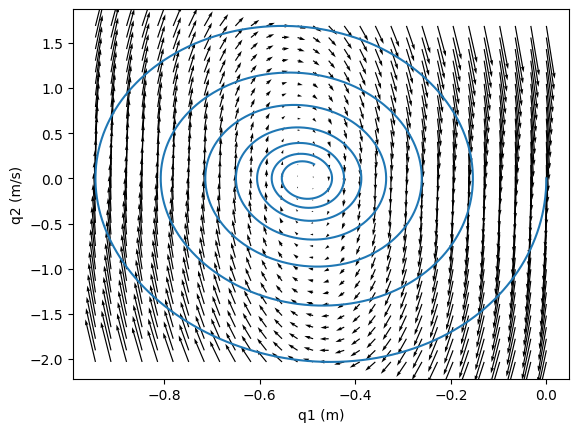

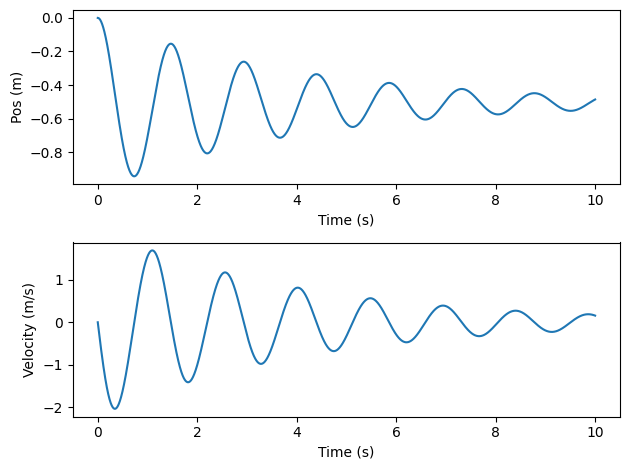

In [28]:
# Problema masa resorte libre clase intro a vibraciones
k,m,g,c,t=sympy.symbols('k,m,g,c,t')
y=dynamicsymbols('y')

N=ReferenceFrame('N')
Fr=-k*y*N.y
Fc=-c*y.diff(t)*N.y
eqF=Fr+Fc-m*g*N.y-m*y.diff(t,t)*N.y

# Otro modelo con terminos no lineales
eqF=Fr+Fc-m*g*N.y-m*y.diff(t,t)*N.y-m*g*sympy.sin(y)*N.y

yddot_sln=sympy.solve(eqF.dot(N.y),y.diff(t,t))[0]
params={k:10.0,m:1.0,g:9.81,c:0.5}
yddot=yddot_sln.subs(params)
yddot_fun=sympy.lambdify([y,y.diff(t)],yddot.subs(params))

def odefun(q,t=None):
    q0dot=q[1]
    q1dot=yddot_fun(q[0],q[1])
    qdot=np.array([q0dot,q1dot])
    return qdot


# Trayectoria desde condicion inicial
q0=[0,0]
tt=np.linspace(0,10,10000)
qt=scipy.integrate.odeint(odefun,q0,tt)

qq0=np.linspace(np.min(qt[:,0]),np.max(qt[:,0]),30)
qq1=np.linspace(np.min(qt[:,1]),np.max(qt[:,1]),30)
grid=np.meshgrid([qq0,qq1])
qq=np.zeros([len(qq0),len(qq1),2])
X,Y=np.meshgrid(qq0,qq1,indexing='ij')
for i in range(0,len(qq0)):
    for j in range(0,len(qq1)):
        qdot=odefun([qq0[i],qq1[j]],0)
        qq[i,j,:]=qdot

fig,ax=plt.subplots(1,1)
ax.quiver(X,Y,qq[:,:,0],qq[:,:,1],scale=100)
ax.plot(qt[:,0],qt[:,1])
ax.set_xlabel('q1 (m)')
ax.set_ylabel('q2 (m/s)')


# Desplazamiento en el tiempo
fig,ax=plt.subplots(2,1)
ax[0].plot(tt,qt[:,0])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Pos (m)')
ax[1].plot(tt,qt[:,1])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Velocity (m/s)')
fig.tight_layout()

# Prueben cambiar el valor de c y ver que pasa.
# Pueben variar la condicion inicial del pendulo y ver que pasa.

In [29]:
yddot

-10.0*y(t) - 9.81*sin(y(t)) - 0.5*Derivative(y(t), t) - 9.81

In [30]:
# Ahora revisemos qdot=f(q)
q1,q2=dynamicsymbols('q1,q2')

fq=sympy.Matrix([y.diff(t),yddot]).subs({y.diff(t):q2,y:q1})
fq

Matrix([
[                                           q2(t)],
[-10.0*q1(t) - 0.5*q2(t) - 9.81*sin(q1(t)) - 9.81]])

In [31]:
# Claramente fq no es lineal en q y no podemos expresarla como [A]q
# Linealizamos alrededor del punto de equilibrio
q_eq=scipy.optimize.fsolve(lambda x: sympy.lambdify([q1,q2],fq)(*x).flatten(),np.array([0,0]))
q_eq={q1:q_eq[0],q2:q_eq[1]}
fq_lineal=fq.diff(q1).subs(q_eq)*q1+fq.diff(q2).subs(q_eq)*q2
fq_lineal

Matrix([
[                              q2(t)],
[-18.5819222656126*q1(t) - 0.5*q2(t)]])

In [32]:
# Probemos la odefun lineal. Observe que q1 en este caso es
# la posición respecto al punto de equilibrio y no la posición
# absoluta.
fq_lineal_fun=sympy.lambdify([q1,q2],fq_lineal)
def odefun_lineal(q,t=None):    
    qdot=fq_lineal_fun(*q).flatten()       
    return qdot

q0=np.array([0.0,0.0],dtype=np.float64)
odefun_lineal(q0)

array([ 0., -0.])

## Comparar linearlización vs el modelo original

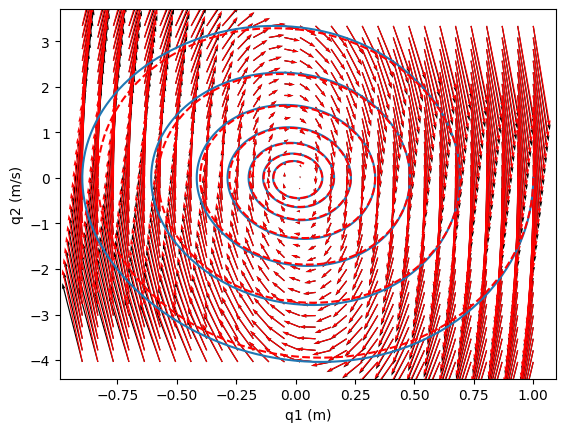

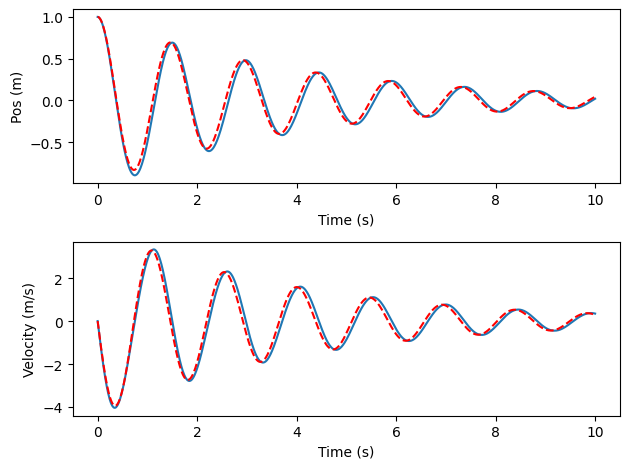

In [33]:
# Trayectoria desde una condicion inicial. La posición está
# definida respecto al punto de equilibrio

q0=np.array([1,0.0])

tt=np.linspace(0,10,1000)
q_eq_vals=np.array(list(q_eq.values()),dtype=np.float64)
qt=scipy.integrate.odeint(odefun,q0+q_eq_vals,tt)-q_eq_vals
qt_lineal=scipy.integrate.odeint(odefun_lineal,q0,tt)

qq0=np.linspace(np.min(qt[:,0]),np.max(qt[:,0]),30)
qq1=np.linspace(np.min(qt[:,1]),np.max(qt[:,1]),30)
grid=np.meshgrid([qq0,qq1])
qq=np.zeros([len(qq0),len(qq1),2])
qq_lineal=np.zeros([len(qq0),len(qq1),2])
X,Y=np.meshgrid(qq0,qq1,indexing='ij')
for i in range(0,len(qq0)):
    for j in range(0,len(qq1)):
        qdot=odefun([qq0[i],qq1[j]]+q_eq_vals)
        qdot_lineal=odefun_lineal([qq0[i],qq1[j]])
        qq[i,j,:]=qdot
        qq_lineal[i,j,:]=qdot_lineal


fig,ax=plt.subplots(1,1)
ax.quiver(X,Y,qq[:,:,0],qq[:,:,1],scale=100)
ax.quiver(X,Y,qq_lineal[:,:,0],qq_lineal[:,:,1],color='r',scale=100)
ax.plot(qt[:,0],qt[:,1])
ax.plot(qt_lineal[:,0],qt_lineal[:,1],'r--')
ax.set_xlabel('q1 (m)')
ax.set_ylabel('q2 (m/s)')

# Desplazamiento del péndulo en el tiempo
fig,ax=plt.subplots(2,1)
ax[0].plot(tt,qt[:,0])
ax[0].plot(tt,qt_lineal[:,0],'r--')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Pos (m)')
ax[1].plot(tt,qt[:,1])
ax[1].plot(tt,qt_lineal[:,1],'r--')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Velocity (m/s)')
fig.tight_layout()

# probar otros valores para condiciones iniciales y ver el resultado
# En rojo vemos el modelo aproximado linealmente sobre la grafica del modelo original (azul)
# Observe que ambos son identicos para el sistema masa resorte amortiguador
# dado que el sistema es lineal si se trabaja q1 como valor respecto al punto de equilibrio.
# Pruebe alterar el modelo, modificando la funcion y agregando terminos tipo sin(x).abs
# Obserque que en ese caso hay diferencias entre el modelo en rojo y azul.

In [34]:
# Con la linealización, ahora tenemos fq de la forma f(q)=A*q
# Esta forma será util cuando analicemos sistemas de mayor dimensión.
A,_=sympy.linear_eq_to_matrix(fq_lineal,[q1,q2])
A

Matrix([
[                0,    1],
[-18.5819222656126, -0.5]])

### Solución analítica a la ecuación diferencial 

In [35]:
# Preguntas preparatorias:
# ¿Cuál es la solución de una ecuacion escalar xdot=k*x 
# ¿Cómo se relaciona esta forma de solución exponencial al caso vectorial qdot=A*q?
# ¿Qué significan los valores/vectores propios de una matriz A y cómo se relacionan con la solucion q(t)?

In [36]:
# Veamos lo básico de ecuaciones diferenciales.
# Solución a ecuación escalar tipo m*xdot=k*x (orden 1)
x=dynamicsymbols('x') 
k=symbols('k')
sympy.dsolve(x.diff(t)-k*x)

Eq(x(t), C1*exp(k*t))

In [37]:
# Veamos lo básico de ecuaciones diferenciales
# Solución a ecuación escalar de segundo orden
x=dynamicsymbols('x')
a,b,c=symbols('a,b,c')
eq=a*x.diff(t,t)-b*x.diff(t)-c*x
sympy.dsolve(eq)

Eq(x(t), C1*exp(t*(b - sqrt(4*a*c + b**2))/(2*a)) + C2*exp(t*(b + sqrt(4*a*c + b**2))/(2*a)))

In [38]:
# Relacion con la matriz A viendo el sistema
# de segundo orden en versión matricial qdot=A*q
q1,q2=dynamicsymbols('q1,q2')
eq=a*x.diff(t,t)+b*x.diff(t)+c*x
eqList=[eq.subs({x.diff(t,t):q2.diff(t),x.diff(t):q2,x:q1}),q1.diff(t)-q2]
fq=sympy.solve(eqList,[q1.diff(t),q2.diff(t)])
fq

{Derivative(q1(t), t): q2(t), Derivative(q2(t), t): -b*q2(t)/a - c*q1(t)/a}

In [39]:
A,b=sympy.linear_eq_to_matrix([fq[q1.diff(t)],fq[q2.diff(t)]],[q1,q2])
A

Matrix([
[   0,    1],
[-c/a, -b/a]])

In [40]:
# Calcular los valores propios de la matriz A
eigen=A.eigenvals(multiple=True)
eigen[0]

-b/(2*a) - sqrt(-4*a*c + b**2)/(2*a)

In [41]:
eigen[1]

-b/(2*a) + sqrt(-4*a*c + b**2)/(2*a)

In [42]:
# Preguntas preparatorias
# ¿Qué significan los valores propios de una matriz?
# ¿Cómo relacionamos los valores propios con la solución de la ecuación diferencial?
# Revisar qué pasa dependiendo de si lambda es complejo o real. Si b es positivo o negativo.
# Revisar la identidad de euler y mirar pág 588 del libro
# Revisar la transformada de fourier y laplace si quiere
# complementar esto con mayor profundidad.

In [43]:
# En clase vimos la ventaja de expresar el estado del sistema en el espacio de los vectores propios.
# Los valores propios son el lambda que da el exponente de la solución al sistema.

# Revisamos qué pasa con la forma de la solución dependiendo de los valores de a,b,c
x=dynamicsymbols('x')
a,b,c,t=symbols('a,b,c,t')
eq=a*x.diff(t,t)-b*x.diff(t)-c*x
sympy.dsolve(eq)


Eq(x(t), C1*exp(t*(b - sqrt(4*a*c + b**2))/(2*a)) + C2*exp(t*(b + sqrt(4*a*c + b**2))/(2*a)))

## Vibracion Forzada

-10.0*y(t) - 10.0*sin(18.8495559215388*t) - 0.5*Derivative(y(t), t)


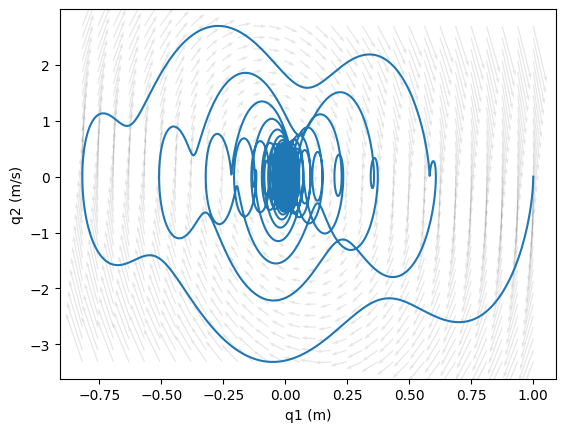

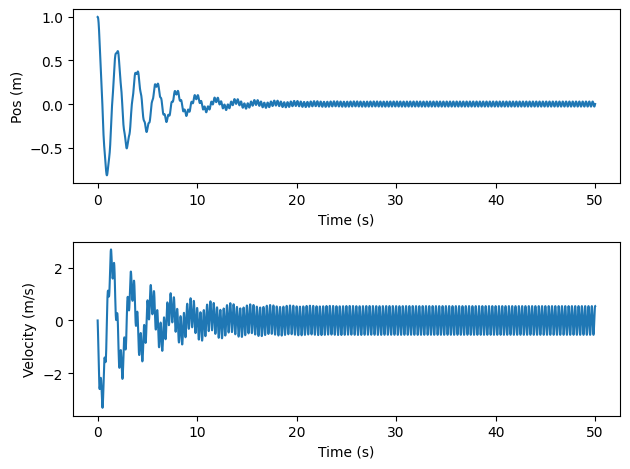

In [44]:
# Problema masa resorte amortiguador con una entrada externa de fuerza
# Estamos modelando respecto al punto de equilibrio, observe que 
# no hay m*g en la eqF. Pero en este caso hay una fuerza externa Fext
# que depende del tiempo.

k,m,c,t,Fext=sympy.symbols('k,m,c,t,Fext')
y=dynamicsymbols('y')

N=ReferenceFrame('N')
Fr=-k*y*N.y
Fc=-c*y.diff(t)*N.y
eqF=Fr+Fc-Fext*N.y-m*y.diff(t,t)*N.y

yddot_sln=sympy.solve(eqF.dot(N.y),y.diff(t,t))[0]
params={k:10.0,m:1.0,g:9.81,c:0.5,Fext:10*sympy.sin(2*np.pi*(3.0)*t)} # Recordar w=2*pi*f, en este caso f=3 Hz
yddot=yddot_sln.subs(params)
print(yddot)
yddot_fun=sympy.lambdify([y,y.diff(t),t],yddot.subs(params))

def odefun(q,t=None):
    q0dot=q[1]
    q1dot=yddot_fun(q[0],q[1],t)
    qdot=np.array([q0dot,q1dot])
    return qdot


# Trayectoria desde condicion inicial
q0=[1,0]
tt=np.linspace(0,50,10000)
qt=scipy.integrate.odeint(odefun,q0,tt)

qq0=np.linspace(np.min(qt[:,0]),np.max(qt[:,0]),30)
qq1=np.linspace(np.min(qt[:,1]),np.max(qt[:,1]),30)
grid=np.meshgrid([qq0,qq1])
qq=np.zeros([len(qq0),len(qq1),2])
X,Y=np.meshgrid(qq0,qq1,indexing='ij')
for i in range(0,len(qq0)):
    for j in range(0,len(qq1)):
        qdot=odefun([qq0[i],qq1[j]],0)
        qq[i,j,:]=qdot

fig,ax=plt.subplots(1,1)
ax.quiver(X,Y,qq[:,:,0],qq[:,:,1],scale=100,alpha=0.1)
ax.plot(qt[:,0],qt[:,1])
ax.set_xlabel('q1 (m)')
ax.set_ylabel('q2 (m/s)')


# Desplazamiento en el tiempo
fig,ax=plt.subplots(2,1)
ax[0].plot(tt,qt[:,0])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Pos (m)')
ax[1].plot(tt,qt[:,1])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Velocity (m/s)')
fig.tight_layout()


# Observe que la trayectoria ya no sigue el campo original (flechas negras en el caso anterior).
# porque la fuerza externa va modificando el campo original en cada
# instante del tiempo. Entonces esa fuerza va creando nuevas direcciones
# en las que se mueve la trayectoria en el espacio de estados.

# Tambien observe que la respuesta Pos(m) presenta dos partes
# una parte transitoria que decae con el tiempo y depende de la
# condicion inicial y una parte permanente que depende de la fuerza
# externa aplicada continuamente. En ecuaciones diferenciales aprenderá que una es 
# la solución homogénea y la otra la particular.

# Prueben varios cambiar el valor de c y ver que pasa.
# Pueben variar la condicion inicial del pendulo y ver que pasa.
# Prueben variar la frecuencia de la fuerza externa y ver que pasa.

In [45]:
# Recordemos la expresión para q2dot
q2dot=fq_lineal[1]
q2dot

-18.5819222656126*q1(t) - 0.5*q2(t)

In [46]:
# Volvamos a escribir la ecuacion de segundo orden:
Fext,x=dynamicsymbols('Fext,x')
eq_system=(q2.diff(t)-q2dot).subs({q1:x,q2:x.diff(t)})+Fext/params[m]
eq_system

1.0*Fext(t) + 18.5819222656126*x(t) + 0.5*Derivative(x(t), t) + Derivative(x(t), (t, 2))

In [47]:
zeta,omega_n=symbols('zeta,omega_n')
Uin,x=dynamicsymbols('Uin,x')
eq_order2=(x.diff(t,t)+2*zeta*omega_n*x.diff(t)+omega_n**2*x)+Uin
eq_order2

omega_n**2*x(t) + 2*omega_n*zeta*Derivative(x(t), t) + Uin(t) + Derivative(x(t), (t, 2))

In [48]:
# Identificar los términos
omega_n=sympy.sqrt(eq_system.subs({Fext:0,x.diff(t,t):0,x.diff(t):0,x:1}))
zeta=sympy.sqrt(eq_system.subs({Fext:0,x.diff(t,t):0,x.diff(t):1,x:0}))/(2*omega_n)
omega=symbols('omega')

# Calcular el función para factor de amplificación
M=1/sympy.sqrt((1-(omega/omega_n)**2)**2+(2*zeta*omega/omega_n)**2)
M


1/sqrt(0.00144806723317235*omega**2 + (1 - 0.0538157455243789*omega**2)**2)

Text(0, 0.5, 'Magnification Factor')

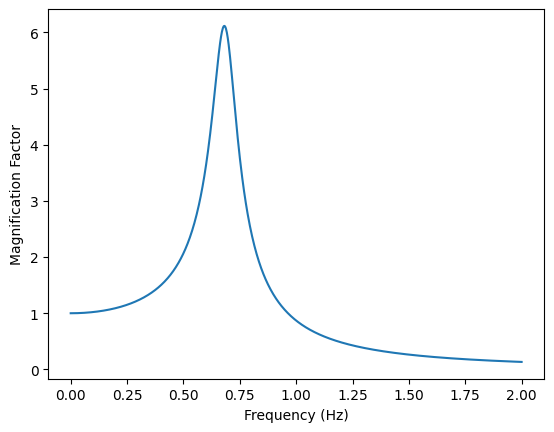

In [49]:
M_fun=sympy.lambdify(omega,M)
ff=np.linspace(0,2,1000) #frecuencias en Hz
MM=M_fun(2*np.pi*ff)

plt.plot(ff,MM)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnification Factor')

In [50]:
# En vez de utilizar la "formula" del libro, podemos generarla usando transformada de laplace

s=symbols('s')
eq=x.diff(t,t)+2*zeta*omega_n*x.diff(t)+omega_n**2*x+Fext
Xs=sympy.laplace_transform(x,t,s,noconds=True)
Fs=sympy.laplace_transform(Fext,t,s,noconds=True)
Eqs=sympy.laplace_transform(eq,t,s,noconds=True).subs({x.diff(t).subs(t,0):0,x.subs(t,0):0})
Xs_sln=sympy.solve(Eqs,Xs)[0]
Gs=Xs_sln/Fs
Gs

-250000000000000.0/(250000000000000.0*s**2 + 176776695296637.0*s + 4.64548056640315e+15)

Text(0, 0.5, 'Magnification Factor')

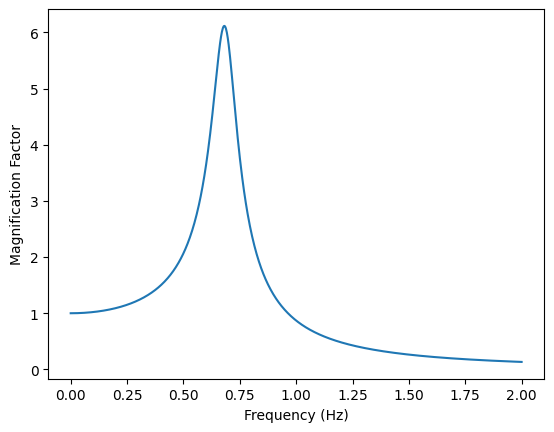

In [51]:
omega=symbols('omega',real=True)
Gw=Gs.subs({s:sympy.I*omega})
Gw_fun=sympy.lambdify(omega,Gw)
Gw_values=Gw_fun(2*np.pi*ff)
MM=[np.absolute(i)*omega_n**2 for i in Gw_values]
plt.plot(ff,MM)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnification Factor')

In [52]:
# Observe que esta gráfica es idéntica a la anterior.
# Es decir, el factor de magnificación corresponde a la magnitud
# de la función de transferencia evaluada en cada s=j*omega.

# Viendo esta grafica, puede devolverse a la simulación con ODEINT
# y probar diferentes frecuencias de entrada en la fuerza externa y ver como
# la respuesta del sistema cambia dependiendo de la cercanía a la 
# frecuencia de resonancia del sistema (pico de la gráfica)